# 神经网络 + 经验回放 + TD 求解贝尔曼方程（状态价值 V(s)）

> 本节用**三层全连接神经网络**替代查表法来拟合状态价值函数 $V(s)$。
> 核心流程：
> 1. 用均匀随机策略采集轨迹，填充**经验回放池**；
> 2. 每步从回放池随机采样一个批次；
> 3. 以 TD 目标 $r + \gamma V(s')$ 作为监督信号，用 MSE 损失训练网络；
> 4. 定期利用网络输出的 $V(s)$ 通过贝尔曼方程推导 $Q(s,a)$，提取贪心策略并可视化。

> **从表格到函数近似**
>
> 表格法把 $V(s)$ 按状态逐一存储，状态一大就同时爆：**存不下**（连续状态无法枚举，差 $0.001$ 在表里就是两个无关的格子）且**不泛化**（没访问过的状态没有估计，相邻格子学到的信息无法共享）。
>
> 解决方案：用带参数 $\mathbf{w}$ 的函数 $\hat{V}(s;\mathbf{w})$ 替代查表：
>
> $$\hat{V}(s;\mathbf{w}) \approx V^\pi(s)$$
>
> 改一次 $\mathbf{w}$，所有状态的估计同步更新——这就是**泛化**。存储量从 $|S|$ 个数降到 $\mathbf{w}$ 的维数。
>
> **目标函数：平稳分布加权均方误差**
>
> 给定固定策略 $\pi$，让 $\hat{V}(s;\mathbf{w})$ 尽量靠近真值 $V^\pi(s)$，定义**加权均方误差**：
>
> $$J(\mathbf{w}) = \mathbb{E}_{\mu}\!\left[\left(V^\pi(s) - \hat{V}(s;\mathbf{w})\right)^2\right] = \sum_s \mu(s)\left(V^\pi(s) - \hat{V}(s;\mathbf{w})\right)^2$$
>
> 其中 $\mu(s)$ 是智能体按策略 $\pi$ 长期运行的**平稳分布**（stationary distribution），满足 $\mu = \mu P$、$\sum_s \mu(s)=1$：常去的状态权重大，很少去的状态允许估差一点。
>
> 实践中无需显式算出 $\mu$——按 $\pi$ 采样时样本自然按访问频率出现，等价于已按 $\mu(s)$ 加权。**经验回放池是这件事的离散版**：池子里出现得多的 $(s,a)$，被抽到的机会也多。
>
> **梯度下降推导**
>
> 对 $J(\mathbf{w})$ 求梯度（常数 $2$ 可吸进学习率）：
>
> $$\nabla_{\mathbf{w}} J(\mathbf{w}) = -2\,\mathbb{E}_\mu\!\left[\left(V^\pi(s) - \hat{V}(s;\mathbf{w})\right)\nabla_{\mathbf{w}}\hat{V}(s;\mathbf{w})\right]$$
>
> 采单样本 $s$ 近似期望（**随机梯度下降**），参数更新公式为：
>
> $$\mathbf{w} \leftarrow \mathbf{w} + \alpha\underbrace{\left(V^\pi(s) - \hat{V}(s;\mathbf{w})\right)}_{\text{误差（估低则正）}}\underbrace{\nabla_{\mathbf{w}}\hat{V}(s;\mathbf{w})}_{\text{误差对参数的敏感方向}}$$
>
> 误差为正（估低了），就沿梯度把估计抬上去；误差为负（估高了），反向压下去。
>
> **TD 目标替换真值**
>
> 真值 $V^\pi(s)$ 不可知，走一步用 **TD 目标**顶替：
>
> $$V^\pi(s) \approx r + \gamma\,\hat{V}(s';\mathbf{w})$$
>
> 代入更新公式，得到**基于值函数近似的 TD 算法**：
>
> $$\boxed{\mathbf{w} \leftarrow \mathbf{w} + \alpha\underbrace{\left(r + \gamma\,\hat{V}(s';\mathbf{w}) - \hat{V}(s;\mathbf{w})\right)}_{\delta\;\text{（TD 误差）}}\nabla_{\mathbf{w}}\hat{V}(s;\mathbf{w})}$$
>
> 与表格 TD 的**唯一差别**：表格只改 $V[s]$ 这一个数；函数近似改整个 $\mathbf{w}$，牵动所有状态的估计。括号内仍是「TD 目标 $-$ 当前估计」，骨架与上节课完全相同。
>
> 终止状态无下一跳，需乘 $(1 - \text{terminal})$ 截断未来（代码里的 `(1.0 - terminal) * gamma * next_state_value`）。

> **线性特例与神经网络**
>
> - **线性近似**：$\hat{V}(s;\mathbf{w}) = \mathbf{w}^T\mathbf{x}(s)$，梯度恰好是特征向量 $\mathbf{x}(s)$，TD 更新退化为 **TD-Linear**：
>   $$\mathbf{w} \leftarrow \mathbf{w} + \alpha\,\delta\,\mathbf{x}(s)$$
> - 取 **one-hot** 特征（第 $s$ 维为 1，其余为 0）时，$\mathbf{w}^T\mathbf{x}(s)$ 就是那张一维价值表，TD-Linear 退化为**表格 TD**。因此：
>   $$\text{表格} \;\subset\; \text{线性函数近似} \;\subset\; \text{一般函数近似（神经网络）}$$
> - **神经网络**（本 notebook）：输入坐标 $(row, col)$，经两层隐藏层自动学非线性特征，输出标量 $\hat{V}$。特征不再手工编写，`loss.backward()` 自动完成梯度计算；标签用 `torch.no_grad()` 固定，对应公式中「目标不随 $\mathbf{w}$ 变」的假设。

# 一、导入必要库

In [12]:
import numpy as np     # 导入 numpy 库，用于数组运算；类型：模块
import random          # 导入 random 库，用于随机数生成；类型：模块
import GridWorld_v3    # 导入自定义 GridWorld_v3 模块，提供网格世界环境；类型：模块
from draw import draw  # 从 draw 模块导入 draw 函数，用于可视化状态值与策略；类型：函数
from ExperienceReplayBuffer import ExperienceReplayBuffer  # 导入经验回放缓冲区类，用于存储与采样历史交互经验；类型：类
import tqdm            # 导入 tqdm 库，用于在训练循环中显示进度条；类型：模块

# 二、环境初始化

In [13]:
rows = 5       # 网格行数，整型，需与 GridWorld_v3 内部行参数保持一致
columns = 5    # 网格列数，整型，需与 GridWorld_v3 内部列参数保持一致
# 创建 5×5 网格世界实例：
#   forbiddenAreaScore=-10：进入禁止区域（'#'）的即时奖励（惩罚），整型
#   score=1：到达目标格（'T'）的即时奖励，整型
#   desc：地图描述列表，每字符串代表一行；'.'普通格，'#'禁止区域，'T'目标格
gridworld = GridWorld_v3.GridWorld_v3(forbiddenAreaScore=-10, score=1,desc = [".....",".##..","..#..",".#T#.",".#..."])
gridworld.show()         # 在控制台打印可视化地图，用于确认环境布局正确
trajectorySteps = 1000   # 每条采样轨迹的最大步数，整型，防止无限循环

⬜️⬜️⬜️⬜️⬜️
⬜️🚫🚫⬜️⬜️
⬜️⬜️🚫⬜️⬜️
⬜️🚫✅🚫⬜️
⬜️🚫⬜️⬜️⬜️


# 三、超参数初始化

In [14]:
# 列表推导：为 5×5=25 个状态各生成一个 (0,1) 均匀随机初始值
# state_values 形状：(25,)，浮点数组，索引对应状态编号 0~24
state_values = np.array([random.random() for i in range(25)])
learning_rate = 0.01  # TD 更新步长（学习率），浮点型，控制每步参数修正幅度
gamma = 0.99          # 折扣因子，浮点型，取值 (0,1]；越接近 1 越重视长远奖励

# 四、神经网络模型定义

In [15]:
import torch                      # 导入 PyTorch 核心库，提供张量运算与自动微分；类型：模块
import torch.nn as nn             # 导入神经网络子模块，提供层与损失函数等；别名 nn
import torch.nn.functional as F   # 导入函数式 API，提供 relu 等激活函数；别名 F
import torch.optim as optim       # 导入优化器子模块，提供 Adam/SGD 等；别名 optim

class model(nn.Module):
    """
    拟合状态价值函数 V(s) 的三层全连接神经网络。

    输入：状态的行列坐标，形状 (batch_size, 2)，float32。
    输出：该状态对应的标量价值估计，形状 (batch_size, 1)，float32。

    网络结构：
        Linear(2 → 128) → ReLU → Linear(128 → 64) → ReLU → Linear(64 → 1)
    """
    def __init__(self):
        """初始化网络结构，定义三个全连接层。"""
        super(model, self).__init__()  # 调用父类 nn.Module 构造函数，完成参数注册
        self.fc1 = nn.Linear(2, 128)   # 第一全连接层：输入维度 2（行坐标、列坐标），输出 128
        self.fc2 = nn.Linear(128, 64)  # 第二全连接层：输入 128，输出 64
        self.fc3 = nn.Linear(64, 1)    # 第三全连接层：输出 1，对应状态价值 V(s) 标量

    def forward(self, state):
        """
        前向传播：将状态坐标映射为状态价值估计。

        参数：
            state (torch.Tensor)：形状 (batch_size, 2)，每行为 [行索引, 列索引]，float32。

        返回：
            Q (torch.Tensor)：形状 (batch_size, 1)，每行为对应状态的价值估计，float32。
        """
        h1 = self.fc1(state)   # 第一层线性变换，输出形状 (batch_size, 128)
        h1 = F.relu(h1)        # ReLU 激活，截断负值为 0，形状不变 (batch_size, 128)
        h2 = self.fc2(h1)      # 第二层线性变换，输出形状 (batch_size, 64)
        h2 = F.relu(h2)        # ReLU 激活，形状不变 (batch_size, 64)
        Q = self.fc3(h2)       # 第三层线性变换，输出状态价值，形状 (batch_size, 1)
        return Q

# 五、经验回放池初始化与数据采集

In [16]:
# 创建经验回放缓冲区，最大容量 10000 条；类型：ExperienceReplayBuffer 实例
experiencePool = ExperienceReplayBuffer(max_size=10000)
# 初始化均匀随机策略：每个状态下 5 个动作的概率均为 0.2
# policy 形状：(25, 5)，浮点数组，行=状态编号，列=动作编号
policy = 0.2 * np.ones((rows*columns,5))
# 列表推导：从状态 10 出发、随机初始动作，采集 500 条完整轨迹
# getTrajectoryScore 返回一条轨迹（列表[经验元组]），元组格式：(s, a, r, s', a', done)
episodes = [gridworld.getTrajectoryScore(nowState = 10,action = random.randint(0,4),policy = policy) 
            for i in range(500)]
# 将所有轨迹的每条经验逐一压入回放池
for trajectory in episodes:      # trajectory：单条轨迹，类型 list[tuple]
    for exp in trajectory:       # exp：单条经验元组
        experiencePool.add_expericence(exp)  # 将经验存入回放池；池满时自动覆盖最旧数据

# 六、网络与优化器初始化

In [17]:
lr = 0.001                                          # Adam 优化器学习率，浮点型
network = model()                                   # 实例化状态价值网络；类型：model（nn.Module 子类）
optimizer = optim.Adam(network.parameters(), lr = lr) # 创建 Adam 优化器，管理 network 所有可训练参数
batch_size = 100                                    # 每次梯度更新使用的样本批次大小，整型

# 七、批次数据采样与预处理

In [18]:
# 从回放池随机采样 batch_size 条经验，返回包含 6 个 numpy 数组的元组
batch = experiencePool.sample_batch(batch_size=batch_size)
# 解包批次数据，各数组形状均为 (batch_size,)：
#   tmpstate   - 当前状态索引，整型数组
#   tmpaction  - 当前执行动作索引，整型数组
#   tmpscore   - 即时奖励，浮点数组
#   nextState  - 下一状态索引，整型数组
#   nextAction - 下一动作索引（SARSA 用），整型数组
#   terminal   - 终止标志：1 表示到达终止状态，0 表示继续，浮点数组
tmpstate, tmpaction, tmpscore, nextState, nextAction, terminal = batch

In [19]:
# 将状态索引列变为列向量，形状 (batch_size,) → (batch_size, 1)，便于 hstack 拼接
tmpstate = tmpstate.reshape(batch_size,1)
# 将一维状态索引拆分为 [行, 列] 坐标：整除 5 得行，取余 5 得列
# np.hstack 水平拼接；输出形状 (batch_size, 2)，整型数组
tmpstate = np.hstack((tmpstate // 5, tmpstate % 5))  #将state变成了行列

In [20]:
tmpstate.shape  # 查看预处理后当前状态数组的形状；期望输出：(batch_size, 2)

(100, 2)

In [21]:
tmpstate[:5]  # 打印前 5 行 [行, 列] 坐标，用于验证状态索引拆分是否正确

array([[1, 1],
       [2, 2],
       [4, 1],
       [2, 0],
       [3, 1]], dtype=int32)

# 八、TD + 经验回放训练循环

  0%|          | 0/100000 [00:00<?, ?it/s]

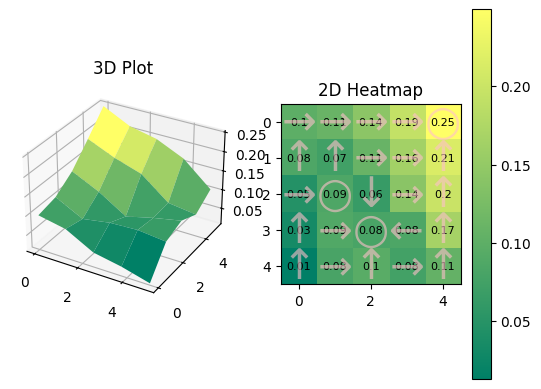

  2%|▏         | 1941/100000 [00:02<02:01, 810.26it/s]

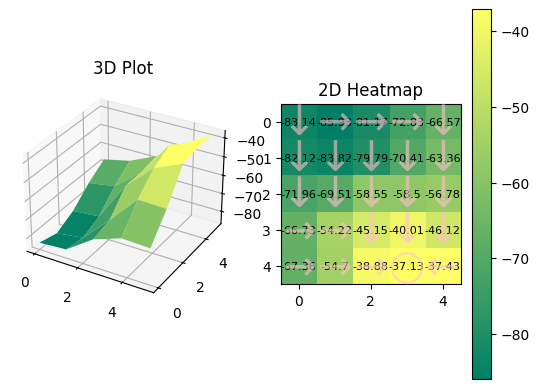

  4%|▍         | 3990/100000 [00:05<01:48, 885.64it/s]

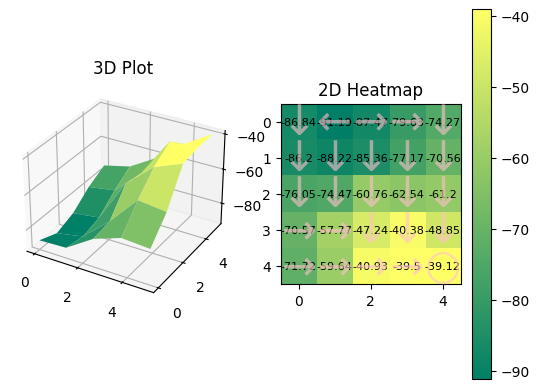

  6%|▌         | 5958/100000 [00:07<01:45, 891.38it/s]

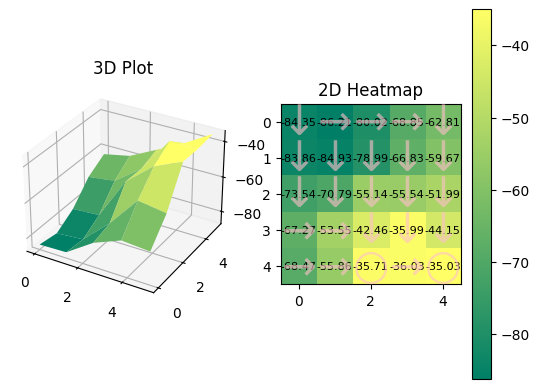

  8%|▊         | 7988/100000 [00:10<01:44, 879.92it/s]

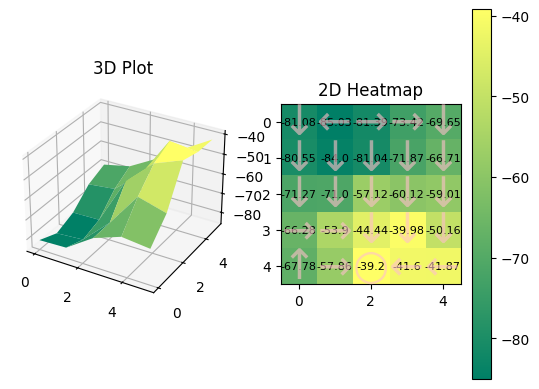

 10%|▉         | 9934/100000 [00:12<01:42, 876.08it/s]

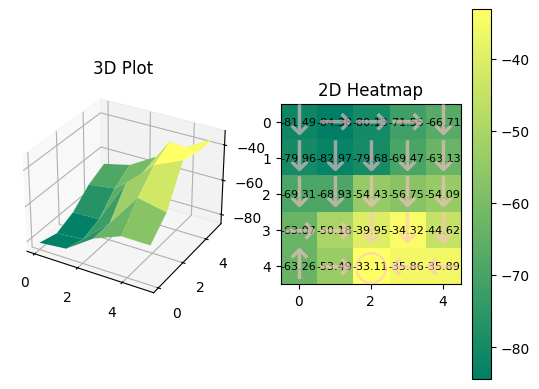

 12%|█▏        | 11961/100000 [00:14<01:45, 834.70it/s]

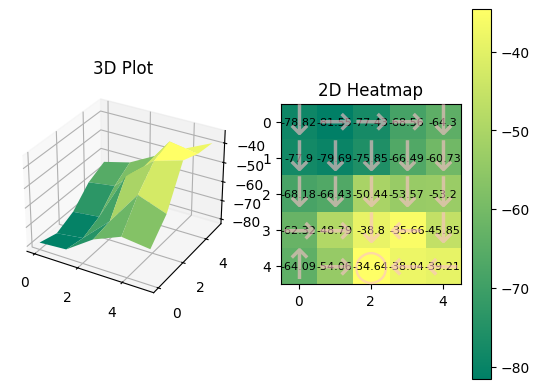

 14%|█▍        | 13980/100000 [00:17<01:38, 872.02it/s]

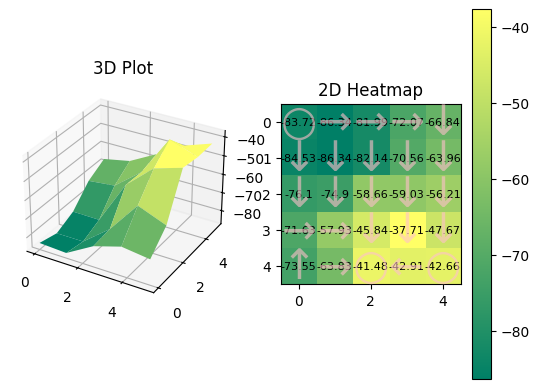

 16%|█▌        | 15991/100000 [00:19<01:37, 865.55it/s]

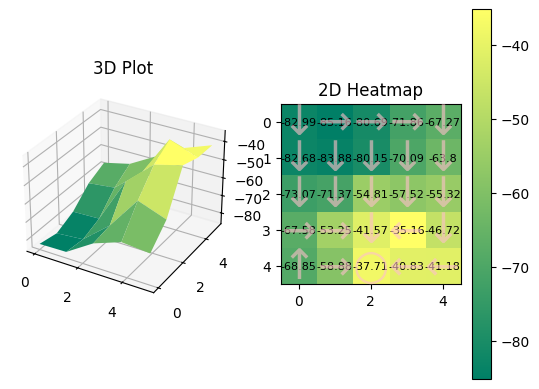

 18%|█▊        | 17927/100000 [00:22<01:35, 862.43it/s]

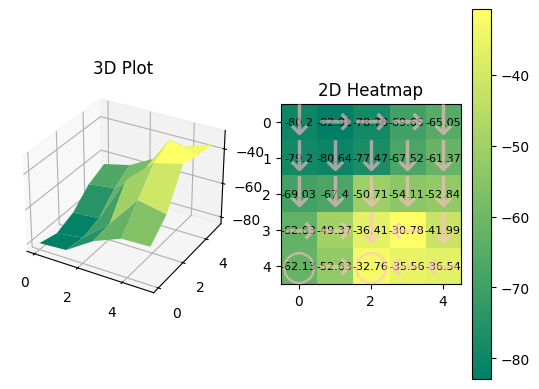

 20%|█▉        | 19922/100000 [00:24<01:34, 849.23it/s]

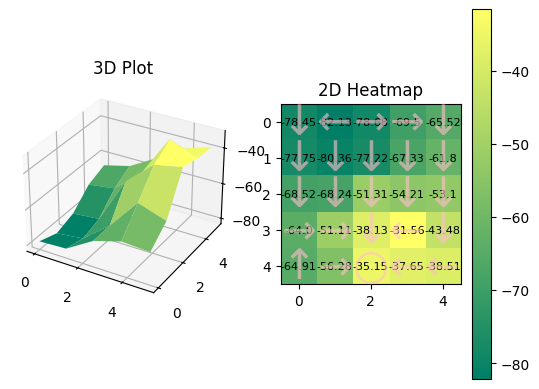

 22%|██▏       | 21951/100000 [00:27<01:29, 875.54it/s]

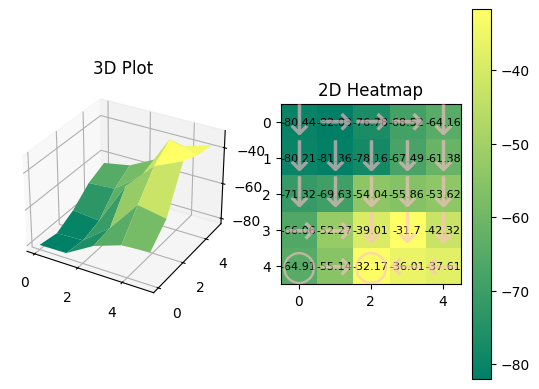

 24%|██▍       | 23940/100000 [00:29<01:25, 894.69it/s]

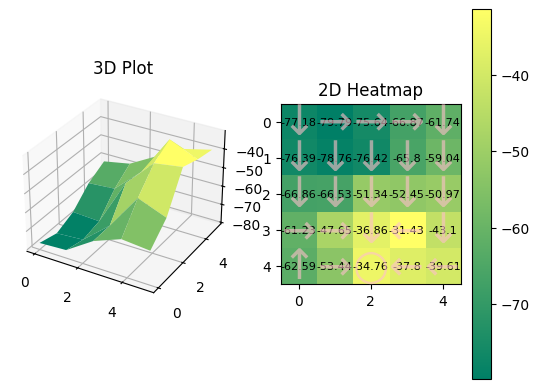

 26%|██▌       | 25917/100000 [00:31<01:27, 846.83it/s]

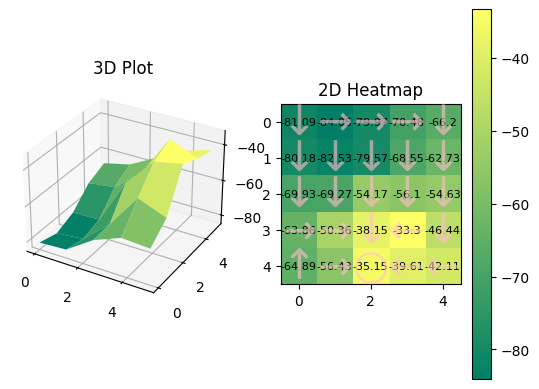

 28%|██▊       | 27930/100000 [00:34<01:22, 870.32it/s]

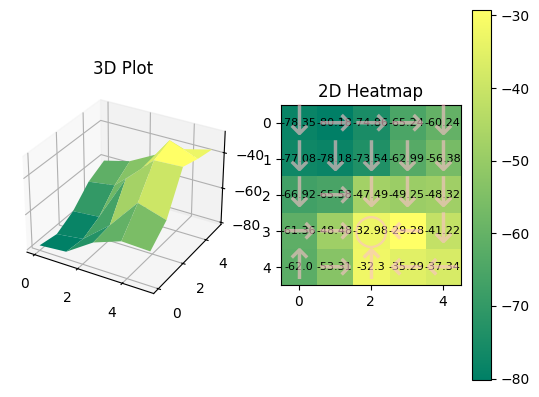

 30%|██▉       | 29950/100000 [00:36<01:20, 867.85it/s]

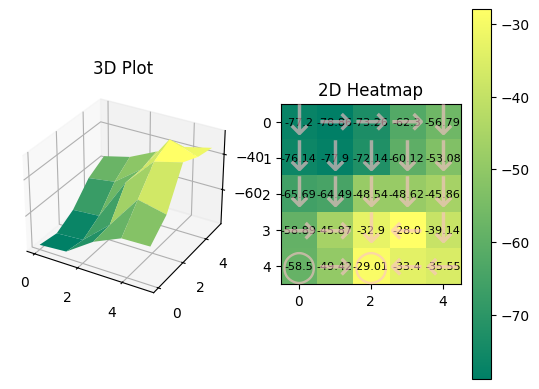

 32%|███▏      | 31925/100000 [00:39<01:17, 883.09it/s]

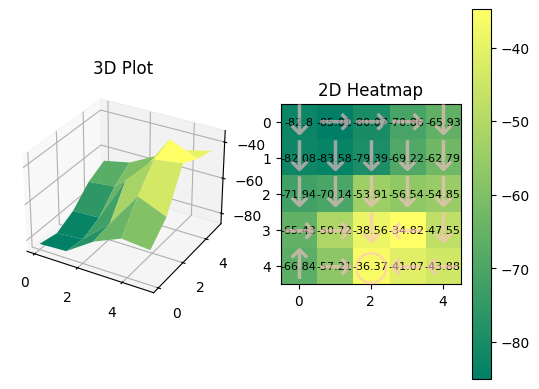

 34%|███▍      | 33960/100000 [00:41<01:16, 865.60it/s]

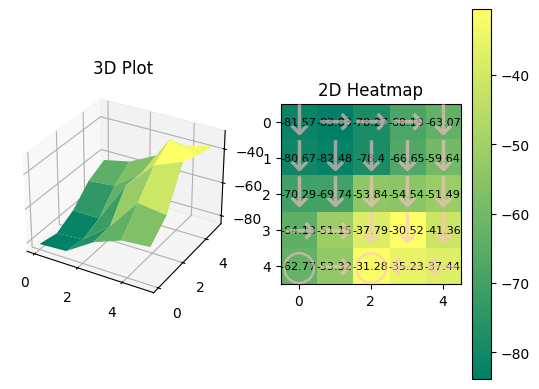

 36%|███▌      | 35938/100000 [00:44<01:09, 915.19it/s]

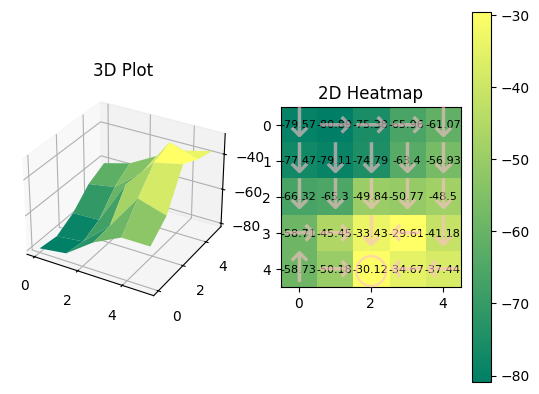

 38%|███▊      | 37940/100000 [00:46<01:10, 884.49it/s]

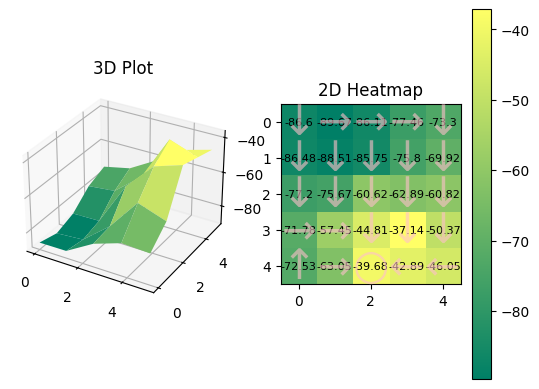

 40%|███▉      | 39931/100000 [00:49<01:03, 942.88it/s]

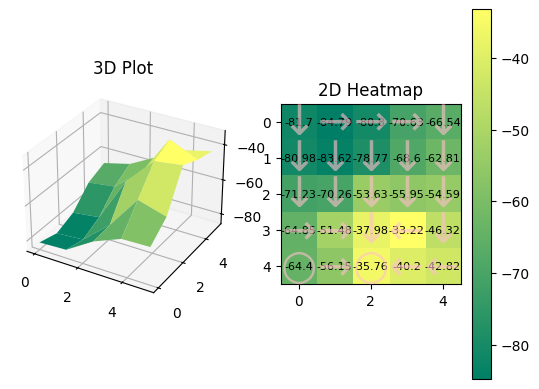

 42%|████▏     | 41945/100000 [00:51<00:57, 1009.50it/s]

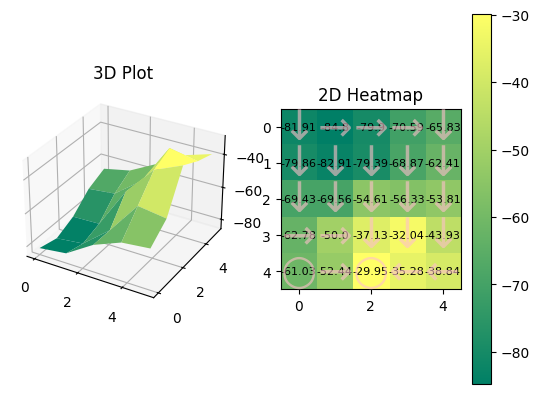

 44%|████▍     | 43945/100000 [00:53<00:58, 958.21it/s] 

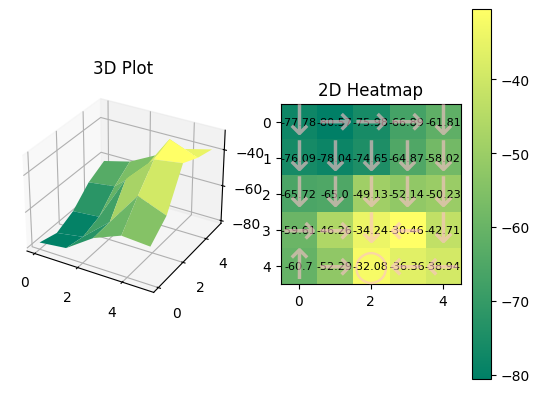

 46%|████▌     | 45949/100000 [00:55<00:56, 963.97it/s]

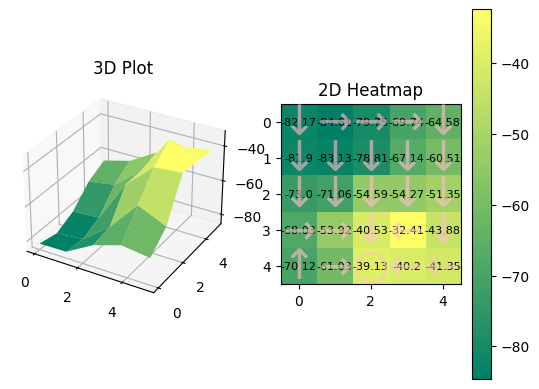

 48%|████▊     | 47961/100000 [00:57<00:52, 991.05it/s] 

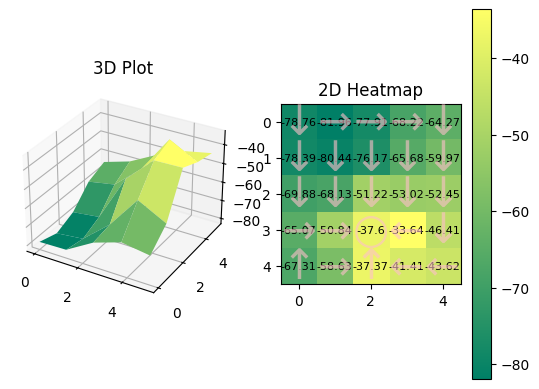

 50%|████▉     | 49971/100000 [00:59<00:55, 908.48it/s] 

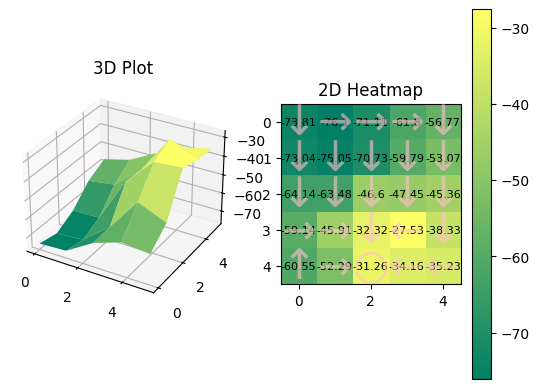

 52%|█████▏    | 51930/100000 [01:02<00:49, 973.87it/s]

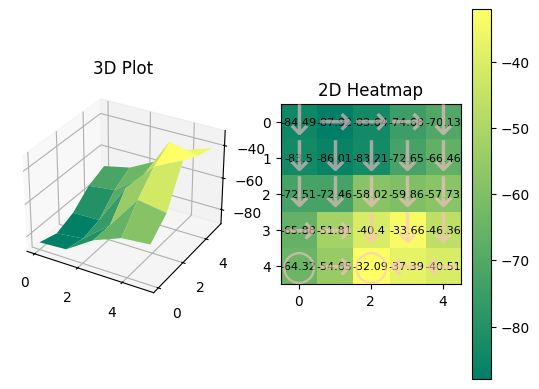

 54%|█████▍    | 53910/100000 [01:04<00:46, 998.25it/s]

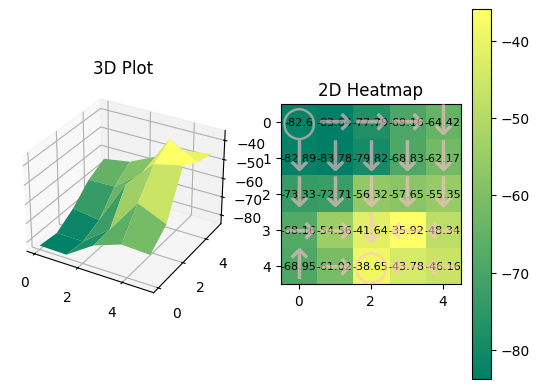

 56%|█████▌    | 55994/100000 [01:06<00:44, 999.58it/s]

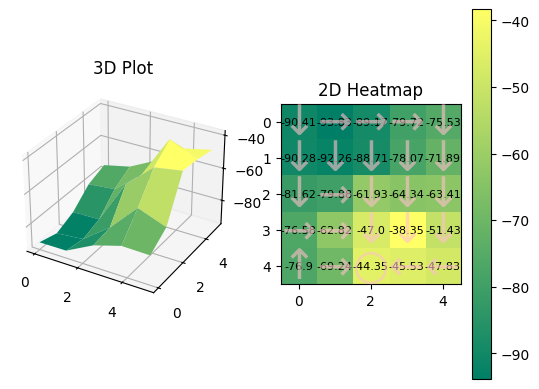

 58%|█████▊    | 57947/100000 [01:08<00:44, 945.22it/s]

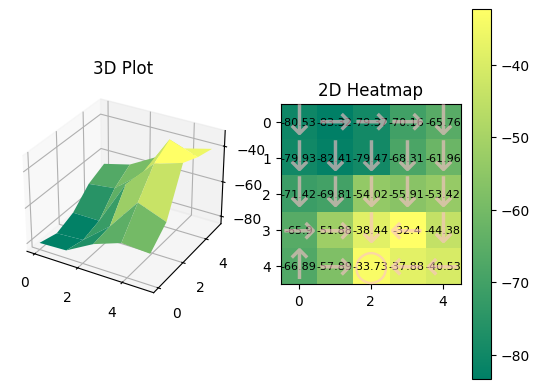

 60%|█████▉    | 59931/100000 [01:11<00:44, 899.63it/s]

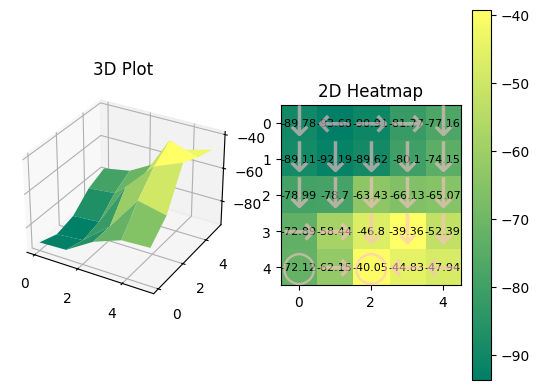

 62%|██████▏   | 61920/100000 [01:13<00:39, 954.63it/s]

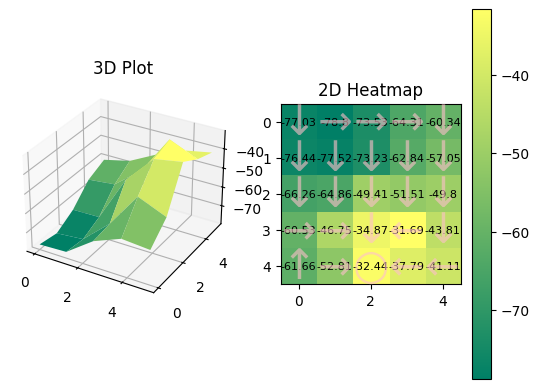

 64%|██████▍   | 63958/100000 [01:15<00:36, 987.59it/s]

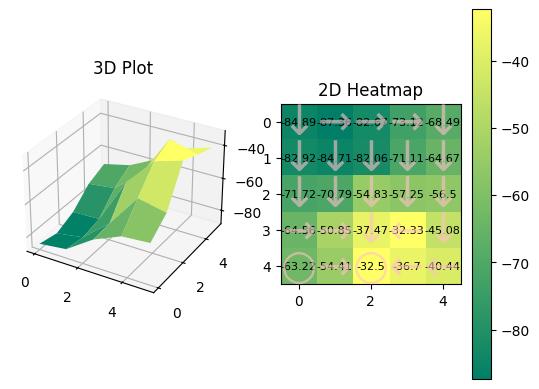

 66%|██████▌   | 65926/100000 [01:17<00:39, 863.84it/s]

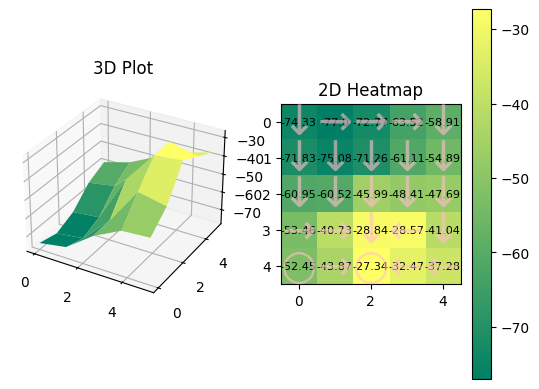

 68%|██████▊   | 67992/100000 [01:20<00:35, 914.36it/s]

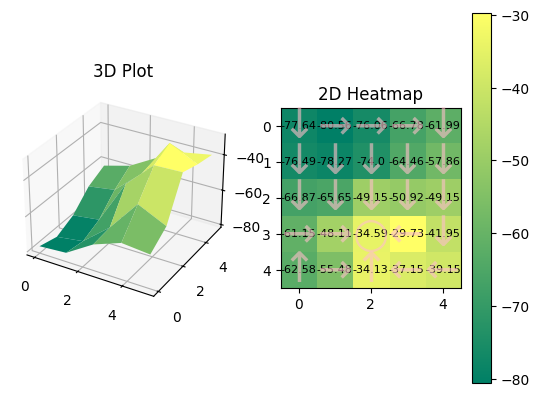

 70%|██████▉   | 69981/100000 [01:22<00:31, 952.97it/s]

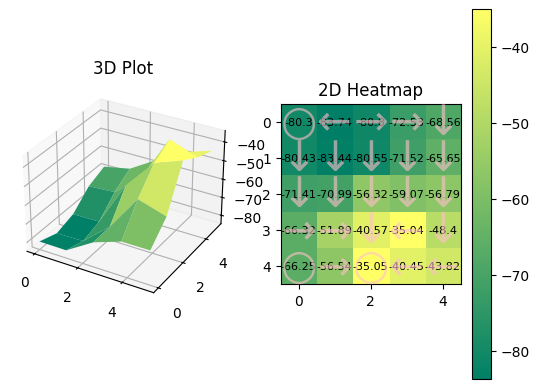

 72%|███████▏  | 71956/100000 [01:24<00:30, 933.76it/s]

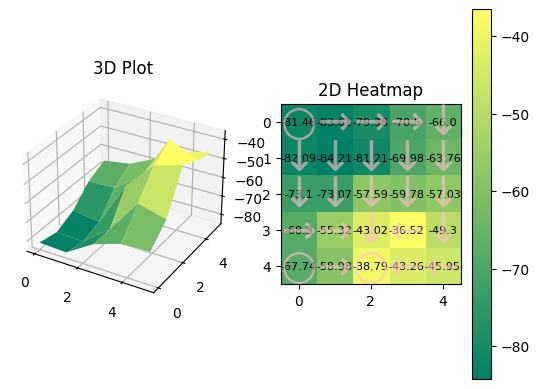

 74%|███████▍  | 73985/100000 [01:27<00:28, 914.67it/s]

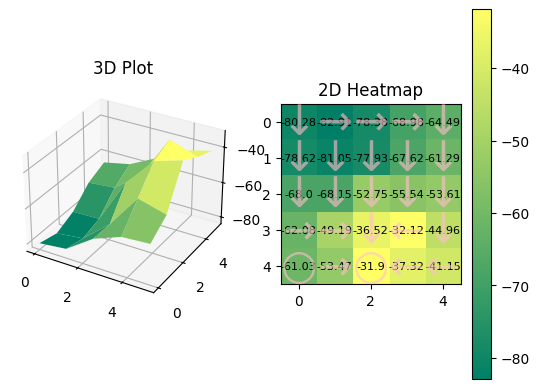

 76%|███████▌  | 75929/100000 [01:29<00:25, 937.36it/s]

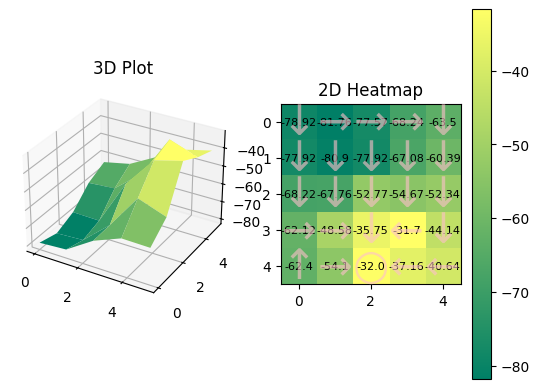

 78%|███████▊  | 77939/100000 [01:31<00:22, 964.02it/s]

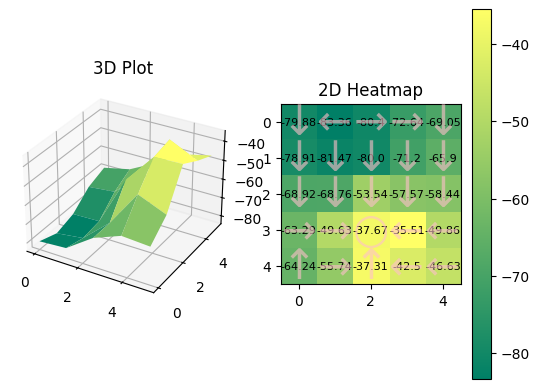

 80%|███████▉  | 79957/100000 [01:33<00:20, 960.46it/s]

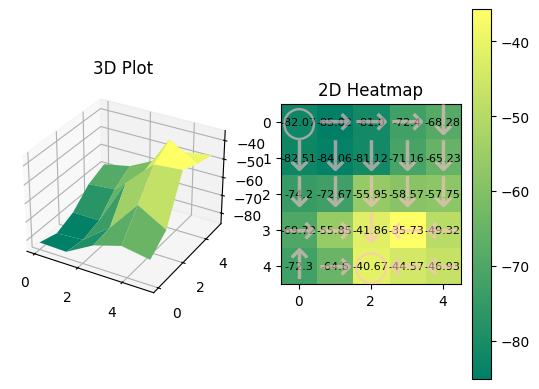

 82%|████████▏ | 81921/100000 [01:36<00:18, 962.15it/s]

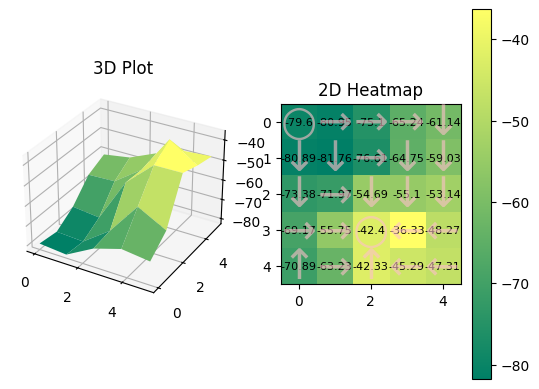

 84%|████████▍ | 83922/100000 [01:38<00:18, 859.06it/s]

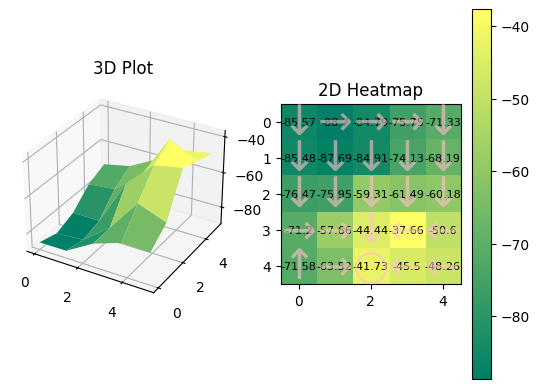

 86%|████████▌ | 85925/100000 [01:40<00:14, 961.64it/s]

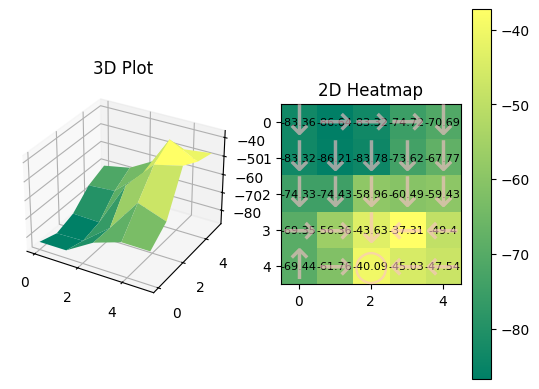

 88%|████████▊ | 87924/100000 [01:42<00:12, 929.05it/s]

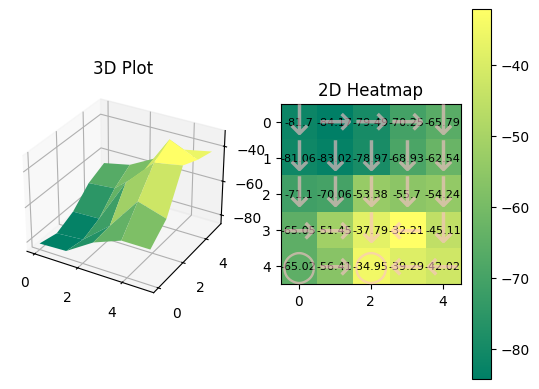

 90%|████████▉ | 89946/100000 [01:45<00:10, 943.55it/s]

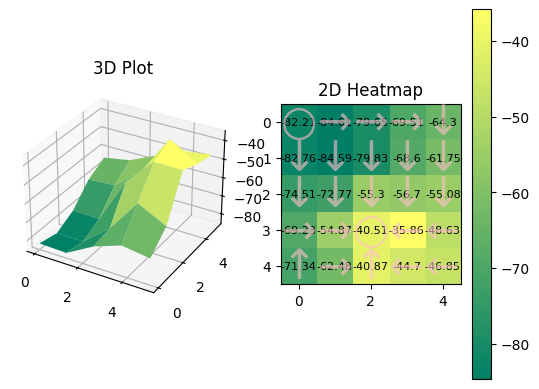

 92%|█████████▏| 91974/100000 [01:47<00:09, 872.26it/s]

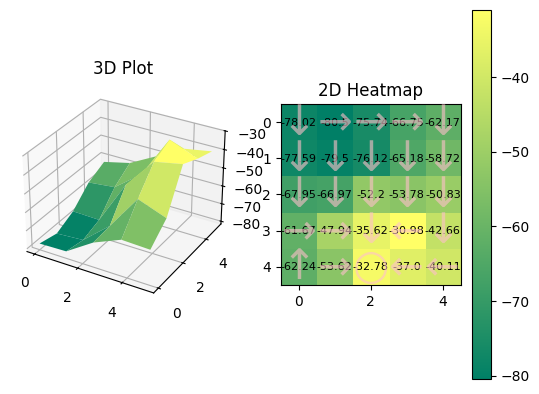

 94%|█████████▍| 93924/100000 [01:49<00:06, 954.53it/s]

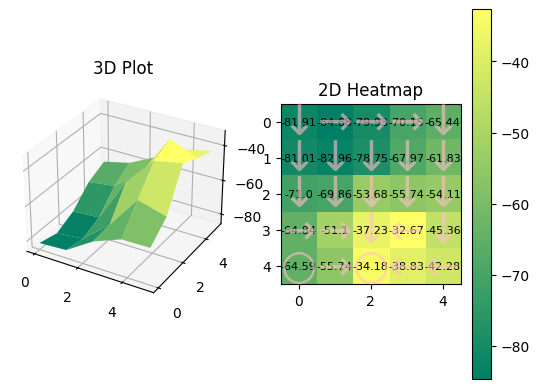

 96%|█████████▌| 95992/100000 [01:52<00:04, 953.11it/s]

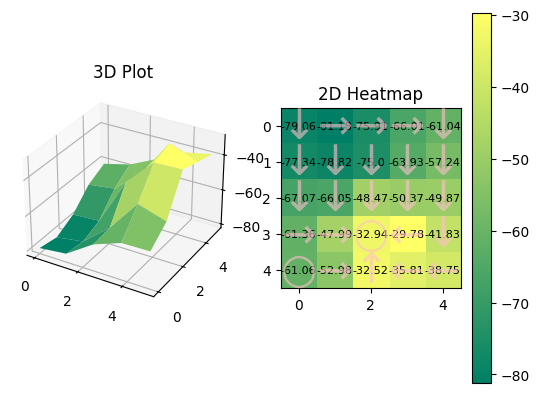

 98%|█████████▊| 97927/100000 [01:54<00:02, 948.88it/s]

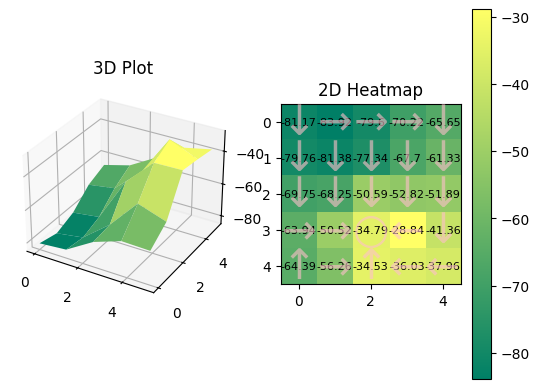

100%|██████████| 100000/100000 [01:56<00:00, 857.58it/s]


In [22]:
# 训练主循环，共迭代 100000 次；tqdm.tqdm 包裹迭代器以显示实时进度条
for _ in tqdm.tqdm(range(100000)):
    # 清空优化器中上一步积累的梯度，防止梯度叠加导致参数更新错误
    optimizer.zero_grad()
    # 从经验回放池随机均匀采样一个批次，返回包含 6 个 numpy 数组的元组
    batch = experiencePool.sample_batch(batch_size=batch_size)
    # 解包批次：各变量形状均为 (batch_size,)
    tmpstate, tmpaction, tmpscore, nextState, nextAction, terminal = batch

    # 当前状态索引整形为列向量，形状 (batch_size, 1)
    tmpstate = tmpstate.reshape(batch_size,1)
    # 转为 [行, 列] 坐标：整除得行，取余得列；输出形状 (batch_size, 2)，整型
    tmpstate = np.hstack((tmpstate // 5, tmpstate % 5))  #将state变成了行列,(bs,2)
    # 下一状态索引整形为列向量，形状 (batch_size, 1)
    nextState = nextState.reshape(batch_size,1)
    # 转为 [行, 列] 坐标；输出形状 (batch_size, 2)，整型
    nextState = np.hstack((nextState // 5, nextState % 5))  #将state变成了行列(bs,2)

    # 转为 PyTorch float32 张量，形状 (batch_size, 2)，作为网络输入
    tmpstate = torch.tensor(tmpstate,dtype = torch.float32).view(batch_size,2)
    # 转为 PyTorch float32 张量，形状 (batch_size, 2)
    nextState = torch.tensor(nextState,dtype = torch.float32).view(batch_size,2)

    # 将当前动作索引转为 int 张量，形状 (batch_size, 1)
    tmpaction = torch.tensor(tmpaction,dtype = torch.int).view(batch_size,1)
    # 将下一动作索引转为 int 张量，形状 (batch_size, 1)
    nextAction = torch.tensor(nextAction,dtype = torch.int).view(batch_size,1)

    # 将即时奖励转为 float32 张量，形状 (batch_size, 1)
    tmpscore = torch.tensor(tmpscore,dtype = torch.float32).view(batch_size,1)
    # 将终止标志转为 float32 张量，形状 (batch_size, 1)；1=终止，0=继续
    terminal = torch.tensor(terminal,dtype = torch.float32).view(batch_size,1)

    # torch.no_grad()：关闭梯度追踪；计算 TD 目标时将 V(s') 视为固定常数，不参与反向传播
    with torch.no_grad():
        # 输入下一状态，得到 V(s') 估计；形状 (batch_size, 1)，float32 张量
        next_state_value = network(nextState)  #网络
        # TD 目标 = r + γ·V(s')·(1-terminal)；终止时未来价值清零；形状 (batch_size, 1)
        target = tmpscore + (1.0 - terminal) * gamma * next_state_value
    
    # 输入当前状态，得到 V(s) 估计；形状 (batch_size, 1)，带梯度的 float32 张量
    now_state_value = network(tmpstate)    #网络
    
    # 计算 MSE 损失：L = mean((V(s) - target)²)；标量张量，带梯度
    loss = F.mse_loss(now_state_value, target)
    # 反向传播：计算 loss 对所有可学习参数的梯度
    loss.backward()
    # Adam 优化器根据梯度更新网络参数
    optimizer.step()
            
    # 每训练 2000 步进行一次策略评估与可视化
    if _ % 2000 == 0:
        # 生成所有 25 个状态的索引列向量，形状 (25, 1)
        s = np.array([[i] for i in range(25)])
        # 转为 [行, 列] 坐标；形状 (25, 2)，整型
        s = np.hstack((s // 5, s % 5))
        # 转为 float32 张量，形状 (25, 2)，输入网络
        states = torch.tensor(s, dtype = torch.float32).view(25,2)
        # 推断全部状态价值；detach() 断开梯度，numpy() 转 numpy；形状 (25,)，浮点数组
        state_values = network(states).view(-1).detach().numpy()  # 还原成state_values
        
        # 初始化动作价值矩阵，形状 (25, 5)，后续逐元素填充
        action_values = np.random.rand(25,5)
        # 贝尔曼方程：Q(s,a) = r + γ·V(s')，遍历所有状态和动作
        for i in range(25):          # 遍历 25 个状态
            for j in range(5):       # 遍历 5 个动作
                # getScore(s, a) 返回 (即时奖励 float, 下一状态索引 int)
                score, nextState = gridworld.getScore(i,j)
                # 动作价值 = 即时奖励 + 折扣 × 下一状态价值
                action_values[i][j] = score + gamma * state_values[nextState]
        
        # 对每个状态取 Q 值最大的动作，得到贪心策略；形状 (25,)，整型数组
        p = np.argmax(action_values,axis=1)
        # 可视化当前状态价值（5×5 矩阵）和贪心策略方向
        draw(state_values.reshape(5,5), p)